In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# Cấu hình style cho biểu đồ
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

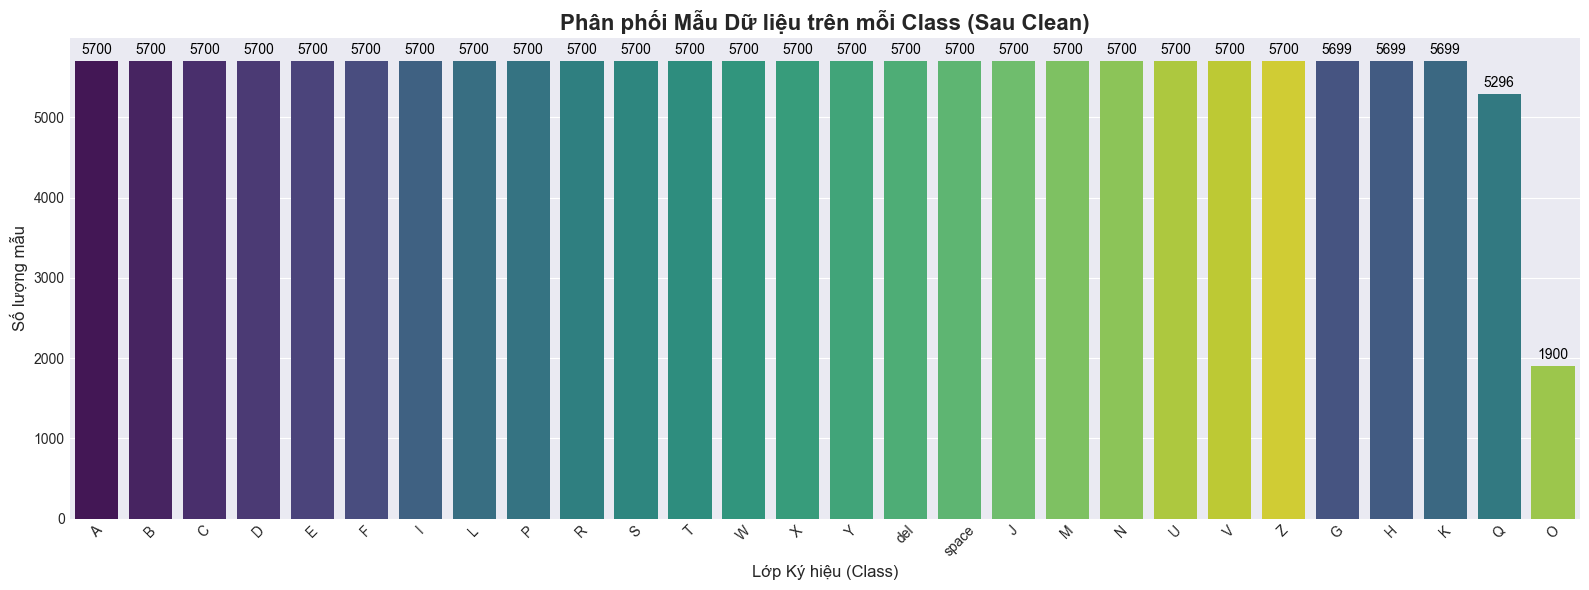

In [8]:
data_path = os.path.join('..', 'data', 'cleaned_data.csv')

if os.path.exists(data_path):
    df = pd.read_csv(data_path, header=None)
    labels = df.iloc[:, 0]
    
    plt.figure(figsize=(16, 6))
    ax = sns.countplot(x=labels, order=labels.value_counts().index, hue=labels, palette="viridis", legend=False) # type: ignore    
    plt.title('Phân phối Mẫu Dữ liệu trên mỗi Class (Sau Clean)', fontsize=16, fontweight='bold')
    plt.xlabel('Lớp Ký hiệu (Class)', fontsize=12)
    plt.ylabel('Số lượng mẫu', fontsize=12)
    
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print(f"❌ Không tìm thấy file tại {data_path}.")

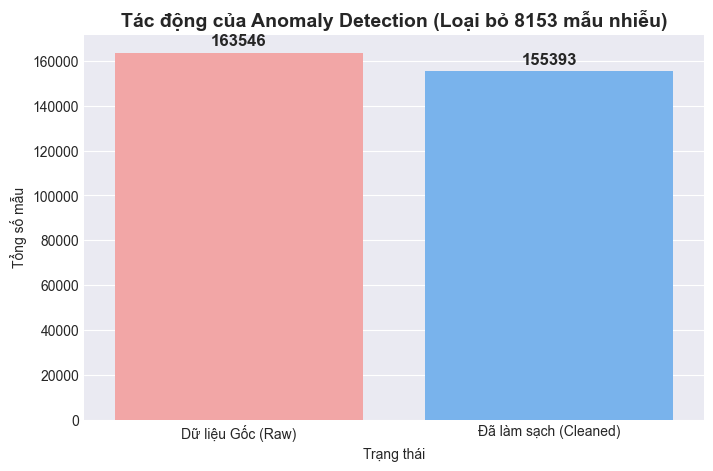

In [9]:
raw_data_path = os.path.join('..', 'data', 'hand_data_all.csv')
clean_data_path = os.path.join('..', 'data', 'cleaned_data.csv')

if os.path.exists(raw_data_path) and os.path.exists(clean_data_path):
    df_raw = pd.read_csv(raw_data_path, header=None)
    df_clean = pd.read_csv(clean_data_path, header=None)
    
    stats = pd.DataFrame({
        'Trạng thái': ['Dữ liệu Gốc (Raw)', 'Đã làm sạch (Cleaned)'],
        'Số dòng': [len(df_raw), len(df_clean)]
    })
    
    plt.figure(figsize=(8, 5))
    sns.barplot(data=stats, x='Trạng thái', y='Số dòng', hue='Trạng thái', palette=['#ff9999', '#66b3ff'], legend=False) # type: ignore    
    plt.title(f'Tác động của Anomaly Detection (Loại bỏ {len(df_raw) - len(df_clean)} mẫu nhiễu)', fontsize=14, fontweight='bold')
    plt.ylabel('Tổng số mẫu')
    
    for i, v in enumerate(stats['Số dòng']):
        plt.text(i, v + (v*0.02), str(v), ha='center', fontweight='bold', fontsize=12)
        
    plt.show()
else:
    print("❌ Vui lòng đảm bảo cả hai file hand_data_all.csv và cleaned_data.csv đều tồn tại.")

 BÁO CÁO ĐÁNH GIÁ MÔ HÌNH (CLASSIFICATION REPORT)
              precision    recall  f1-score   support

           A     1.0000    1.0000    1.0000      1072
           B     1.0000    1.0000    1.0000      1118
           C     1.0000    1.0000    1.0000      1115
           D     1.0000    1.0000    1.0000      1118
           E     1.0000    1.0000    1.0000      1134
           F     1.0000    1.0000    1.0000      1201
           G     1.0000    1.0000    1.0000      1095
           H     1.0000    1.0000    1.0000      1180
           I     1.0000    1.0000    1.0000      1119
           J     1.0000    1.0000    1.0000      1186
           K     1.0000    1.0000    1.0000      1123
           L     1.0000    1.0000    1.0000      1157
           M     1.0000    1.0000    1.0000      1168
           N     1.0000    1.0000    1.0000      1173
           O     1.0000    1.0000    1.0000       362
           P     1.0000    1.0000    1.0000      1184
           Q     1.0000    1.00

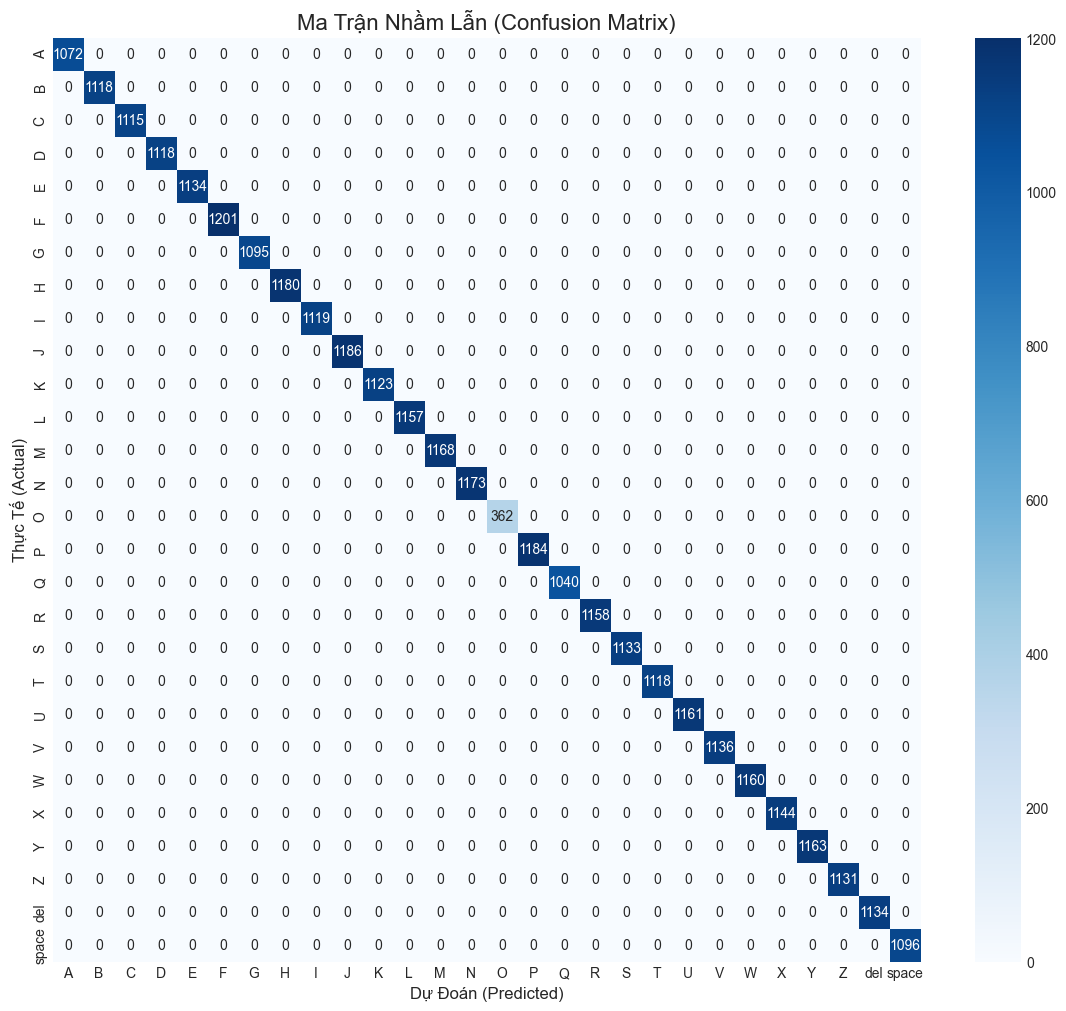

In [10]:
clean_data_path = os.path.join('..', 'data', 'cleaned_data.csv')
model_path = os.path.join('..', 'models', 'sign_language_model.pkl')

if os.path.exists(clean_data_path) and os.path.exists(model_path):
    df = pd.read_csv(clean_data_path, header=None)
    X = df.iloc[:, 1:].values 
    y = df.iloc[:, 0].values
    
    # Chia test set giống với lúc train để lấy metrics chính xác
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    rf_model = joblib.load(model_path)
    y_pred = rf_model.predict(X_test)
    
    print("="*60)
    print(" BÁO CÁO ĐÁNH GIÁ MÔ HÌNH (CLASSIFICATION REPORT)")
    print("="*60)
    # Lấy 3 chỉ số classification metrics quan trọng nhất
    report = classification_report(y_test, y_pred, digits=4)
    print(report)
    
    # Plot heatmap
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
    plt.title("Ma Trận Nhầm Lẫn (Confusion Matrix)", fontsize=16)
    plt.xlabel('Dự Đoán (Predicted)', fontsize=12)
    plt.ylabel('Thực Tế (Actual)', fontsize=12)
    plt.show()
else:
    print("❌ Thiếu model hoặc data để tạo báo cáo đánh giá.")

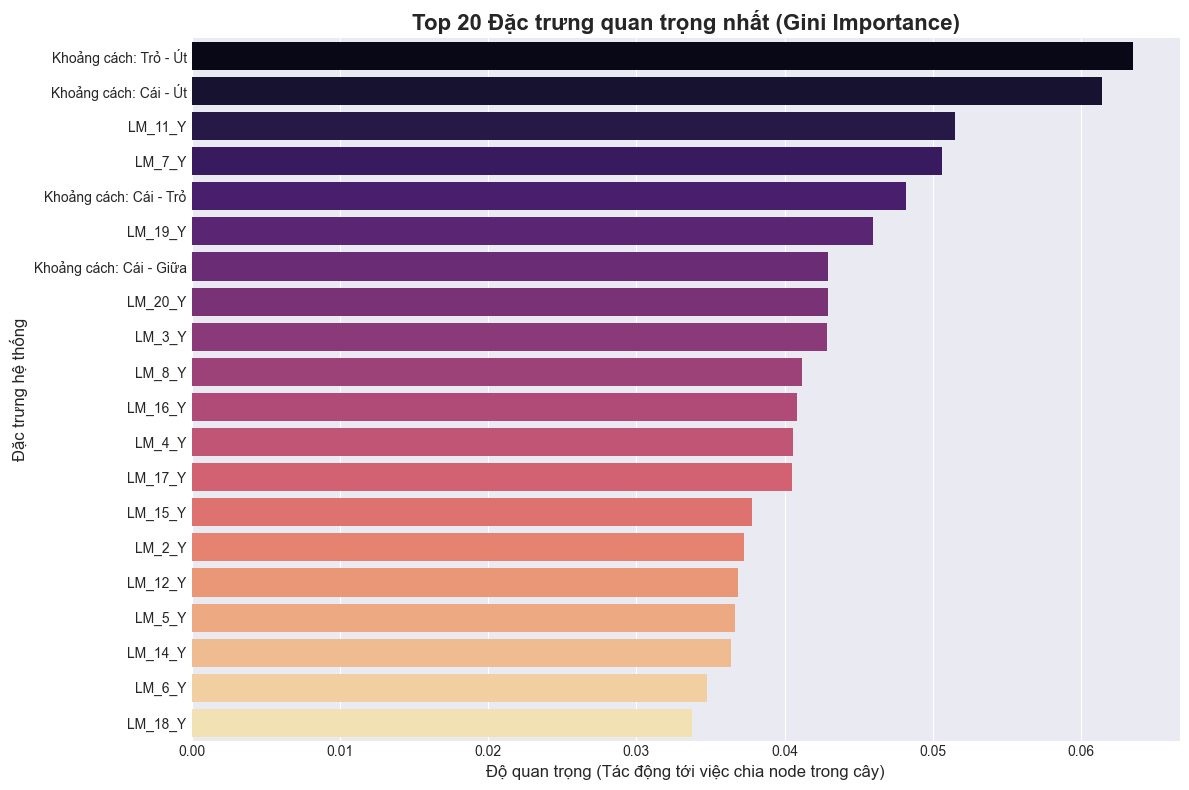

In [11]:
model_path = os.path.join('..', 'models', 'sign_language_model.pkl')

if os.path.exists(model_path):
    rf_model = joblib.load(model_path)
    importances = rf_model.feature_importances_
    
    feature_names = []
    for i in range(21):
        feature_names.extend([f'LM_{i}_X', f'LM_{i}_Y'])
    feature_names.extend(['Khoảng cách: Cái - Trỏ', 'Khoảng cách: Cái - Giữa', 'Khoảng cách: Cái - Út', 'Khoảng cách: Trỏ - Út'])
    
    indices = np.argsort(importances)[::-1][:20]
    top_features = [feature_names[i] for i in indices]
    top_importances = importances[indices]
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x=top_importances, y=top_features, hue=top_features, palette="magma", legend=False) # type: ignore    
    plt.title('Top 20 Đặc trưng quan trọng nhất (Gini Importance)', fontsize=16, fontweight='bold')
    plt.xlabel('Độ quan trọng (Tác động tới việc chia node trong cây)', fontsize=12)
    plt.ylabel('Đặc trưng hệ thống', fontsize=12)
    plt.tight_layout()
    plt.show()